# Análisis de Desigualdades Regionales en Hospitalización de Alta Complejidad
## GRD Sistema Público de Salud de Chile – FONASA (2023–2024)

**Integrantes del grupo:** Lukas Garrido, Cristobal Ramirez

---

**Objetivo:** Analizar las desigualdades regionales en la hospitalización de alta complejidad
en el sistema público de salud chileno, identificando patrones de flujo de pacientes,
variaciones en severidad y factores asociados al peso GRD mediante regresión lineal.


---
## 1. Carga de Librerías y Configuración Inicial


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import geopandas
import geodatasets
import warnings
import contextily as ctx
from adjustText import adjust_text
from scipy.stats import chi2_contingency, fisher_exact
from unidecode import unidecode
import statsmodels.formula.api as smf
from statsmodels.stats.proportion import proportion_confint
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")

# Configuración estética global de matplotlib
plt.rcParams.update({
    "figure.dpi": 120,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
})

PALETTE    = "Blues_r"
COLOR_MAIN = "#1f77b4"
COLOR_SEC  = "#d62728"


---
## 2. Carga y Preprocesamiento de Datos

### 2.1 Datos GRD 2023 y 2024

Se cargan los archivos GRD de ambos años. Las columnas de fecha se parsean automáticamente
y las columnas numéricas con valores no estándar se convierten con  (→ NaN).


In [2]:
# ── GRD 2024 ──────────────────────────────────────────────────────────────────
GRD_2024 = pd.read_csv(
    "BDDs/GRD_PUBLICO_2024.csv",
    sep="|", encoding="latin-1", low_memory=False,
    parse_dates=["FECHA_NACIMIENTO", "FECHA_INGRESO", "FECHAALTA"],
    dayfirst=True, date_format="%d/%m/%Y"
)

# ── GRD 2023 ──────────────────────────────────────────────────────────────────
GRD_2023 = pd.read_csv(
    "BDDs/GRD_PUBLICO_2023.csv",
    sep="|", encoding="utf-16", low_memory=False, decimal=",",
    parse_dates=["FECHA_NACIMIENTO", "FECHA_INGRESO", "FECHAALTA"],
    dayfirst=True, date_format="%d/%m/%Y"
)

# Conversión de columnas numéricas con valores no estándar (en ambos datasets)
for df in [GRD_2023, GRD_2024]:
    for col in ["IR_29301_SEVERIDAD", "IR_29301_MORTALIDAD", "IR_29301_COD_GRD"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    df["IR_29301_COD_GRD"] = df["IR_29301_COD_GRD"].fillna(0).astype(str)

print(f"GRD 2023: {len(GRD_2023):,} registros")
print(f"GRD 2024: {len(GRD_2024):,} registros")


GRD 2023: 1,039,587 registros
GRD 2024: 1,085,813 registros


### 2.2 Diccionarios y Establecimientos

Cargamos los diccionarios de hospitales, GRD, severidad y mortalidad, y el dataset de
establecimientos con información geográfica y de complejidad
([fuente](https://datos.gob.cl/dataset/establecimientos-de-salud-vigentes/resource/2c44d782-3365-44e3-aefb-2c8b8363a1bc)).


In [3]:
# Diccionarios
hospitales = pd.read_csv("BDDs/Hospitales.csv", sep="|", encoding="utf-8",
                         header=None, names=["COD_HOSPITAL", "NOMBRE_HOSPITAL"])
irgrd      = pd.read_csv("BDDs/IR-GRD.csv",    sep="|",
                         header=None, names=["COD_GRD", "DESCRIPCION_GRD"])
mortalidad = pd.read_csv("BDDs/Mortalidad.csv", sep="|", encoding="utf-8",
                         header=None, names=["CODIGO", "SEVERIDAD"])
severidad  = pd.read_csv("BDDs/Severidad.csv",  sep="|", encoding="utf-8",
                         header=None, names=["CODIGO", "MORTALIDAD"])

irgrd["COD_GRD"] = irgrd["COD_GRD"].astype(str)
irgrd["GRD_CODIGO_LIMPIO"] = irgrd["COD_GRD"].str.extract(r"(\d+)")

# Establecimientos: solo alta complejidad
establecimientos    = pd.read_csv("BDDs/establecimientos.csv", sep=";", low_memory=False)
establecimientosAlta = establecimientos[
    establecimientos["NivelComplejidadEstabGlosa"] == "Alta Complejidad"
]

print(f"Hospitales de alta complejidad: {len(establecimientosAlta)}")


Hospitales de alta complejidad: 129


### 2.3 Integración de Datasets

Se unen los datos GRD de ambos años con los diccionarios descriptivos (hospital, GRD,
severidad, mortalidad). Luego se filtra a hospitales de alta complejidad, se concatenan
ambos años y se enriquece con coordenadas geográficas y datos comunales del hospital.
Finalmente se crean las variables derivadas principales.


In [4]:
def merge_grd(df):
    """Agrega columnas descriptivas (hospital, GRD, severidad, mortalidad) al DataFrame GRD."""
    df = df.merge(hospitales, on="COD_HOSPITAL", how="left")
    df["GRD_CODIGO_LIMPIO"] = df["IR_29301_COD_GRD"].str.extract(r"(\d+)")
    df = df.merge(irgrd[["GRD_CODIGO_LIMPIO", "DESCRIPCION_GRD"]], on="GRD_CODIGO_LIMPIO", how="left")
    df = df.merge(severidad, left_on="IR_29301_SEVERIDAD", right_on="CODIGO", how="left")
    df = df.merge(mortalidad, left_on="IR_29301_MORTALIDAD", right_on="CODIGO", how="left",
                  suffixes=("_sev", "_mor"))
    return df


GRD_2023_new = merge_grd(GRD_2023)
GRD_2024_new = merge_grd(GRD_2024)

# Filtro de hospitales de alta complejidad
GRD_2023_ALTA = GRD_2023_new[GRD_2023_new["COD_HOSPITAL"].isin(establecimientosAlta["EstablecimientoCodigo"])]
GRD_2024_ALTA = GRD_2024_new[GRD_2024_new["COD_HOSPITAL"].isin(establecimientosAlta["EstablecimientoCodigo"])]

# Unión de ambos años
GRD_ALTA = pd.concat([GRD_2023_ALTA, GRD_2024_ALTA], ignore_index=True)

# Merge con datos geográficos del hospital (latitud, longitud, comuna)
GRD_ALTA = GRD_ALTA.merge(
    establecimientosAlta[["EstablecimientoCodigo", "Latitud", "Longitud", "ComunaCodigo", "ComunaGlosa"]],
    left_on="COD_HOSPITAL", right_on="EstablecimientoCodigo", how="left"
).drop(columns=["EstablecimientoCodigo"])

# Limpieza y normalización de comunas (paciente y hospital)
GRD_ALTA["COMUNA_PAC"]  = GRD_ALTA["COMUNA"].str.strip().str.upper().apply(unidecode)
GRD_ALTA["COMUNA_HOSP"] = GRD_ALTA["ComunaGlosa"].str.strip().str.upper().apply(unidecode)
GRD_ALTA.drop(columns=["COMUNA", "ComunaGlosa"], inplace=True)

# Indicador: paciente atendido fuera de su comuna
GRD_ALTA["FORANEO_COMUNA"] = (
    GRD_ALTA["COMUNA_HOSP"].notna() &
    GRD_ALTA["COMUNA_PAC"].notna() &
    (GRD_ALTA["COMUNA_HOSP"] != GRD_ALTA["COMUNA_PAC"])
)

# Limpieza del peso GRD
GRD_ALTA["IR_29301_PESO"] = (
    GRD_ALTA["IR_29301_PESO"]
    .fillna("1,0")
    .replace({"DESCONOCIDO": "1,0"}, regex=True)
    .replace({",": "."}, regex=True)
)
GRD_ALTA["IR_29301_PESO"]      = pd.to_numeric(GRD_ALTA["IR_29301_PESO"])
GRD_ALTA["IR_29301_SEVERIDAD"] = GRD_ALTA["IR_29301_SEVERIDAD"].fillna(1).astype(int)
GRD_ALTA["COMUNA_PAC"] = GRD_ALTA["COMUNA_PAC"].replace({"COIHAIQUE" : "COYHAIQUE"})
proc_cols = [c for c in GRD_ALTA.columns if c.startswith('PROCEDIMIENTO')]
diag_cols = [c for c in GRD_ALTA.columns if c.startswith('DIAGNOSTICO')]
GRD_ALTA['N_PROCEDIMIENTOS'] = GRD_ALTA[proc_cols].notna().sum(axis=1)
GRD_ALTA['N_DIAGNOSTICOS']   = GRD_ALTA[diag_cols].notna().sum(axis=1)
print(f"GRD_ALTA total: {len(GRD_ALTA):,} registros")


GRD_ALTA total: 1,987,858 registros


### 2.4 Asignación de Macrozona del Paciente

Se agrega la columna  a partir de la región que figura en el
campo  del paciente. La clasificación sigue la división
macrozonal estándar del Ministerio de Salud de Chile:

| Macrozona | Regiones |
|-----------|----------|
| Norte | Arica y Parinacota, Tarapacá, Antofagasta, Atacama |
| Centro-Norte | Coquimbo, Valparaíso |
| Centro | Metropolitana, O'Higgins |
| Centro-Sur | Maule, Ñuble, Biobío |
| Sur | La Araucanía, Los Ríos, Los Lagos |
| Austral | Aysén, Magallanes |


In [5]:
# ── Mapeo región → macrozona ──────────────────────────────────────────────────
# La columna SERVICIO_SALUD contiene la región de atención del paciente.
# Normalizamos el texto y asignamos la macrozona correspondiente.

MACROZONA_MAP = {
    # Norte
    "ARICA":         "Norte",
    "TARAPACA":      "Norte",
    "ANTOFAGASTA":   "Norte",
    "ATACAMA":       "Norte",
    # Centro-Norte
    "COQUIMBO":      "Centro-Norte",
    "VALPARAISO":    "Centro-Norte",
    "ACONCAGUA":     "Centro-Norte",
    # Centro
    "METROPOLITANO": "Centro",
    "NORTE":         "Centro",    # Servicio de Salud Metropolitano Norte
    "SUR":           "Centro",    # Servicio de Salud Metropolitano Sur
    "ORIENTE":       "Centro",    # Servicio de Salud Metropolitano Oriente
    "OCCIDENTE":     "Centro",
    "CENTRAL":       "Centro",
    "OHIGGINS":      "Centro",
    # Centro-Sur
    "MAULE":         "Centro-Sur",
    "NUBLE":         "Centro-Sur",
    "BIOBIO":        "Centro-Sur",
    "CONCEPCION":    "Centro-Sur",
    "ARAUCO":        "Centro-Sur",
    # Sur
    "ARAUCANIA":     "Sur",
    "LOS RIOS":      "Sur",
    "VALDIVIA":      "Sur",
    "LOS LAGOS":     "Sur",
    "RELONCAVI":     "Sur",
    "CHILOE":        "Sur",
    # Austral
    "AYSEN":         "Austral",
    "MAGALLANES":    "Austral",
}


def asignar_macrozona(servicio_salud: str) -> str:
    """Asigna macrozona a partir del texto del campo SERVICIO_SALUD."""
    if pd.isna(servicio_salud):
        return "Desconocida"
    texto = unidecode(str(servicio_salud).upper().strip())
    for clave, macrozona in MACROZONA_MAP.items():
        if clave in texto:
            return macrozona
    return "Desconocida"


GRD_ALTA["MACROZONA_HOSP"] = GRD_ALTA["SERVICIO_SALUD"].apply(asignar_macrozona)

# Resumen de cobertura
dist = GRD_ALTA["MACROZONA_HOSP"].value_counts()
pct  = dist / len(GRD_ALTA) * 100
print("Distribución de pacientes por macrozona:")
print(pd.DataFrame({"N": dist, "%": pct.round(1)}).to_string())


Distribución de pacientes por macrozona:
                     N     %
MACROZONA_HOSP              
Centro          779751  39.2
Centro-Sur      361503  18.2
Desconocida     318427  16.0
Centro-Norte    217475  10.9
Norte           136622   6.9
Sur             126748   6.4
Austral          47332   2.4


---
## 3. Análisis Exploratorio de Datos (EDA)


### 3.1 Valores Ausentes y Tipos de Datos

Revisamos las columnas clave para identificar el porcentaje de nulos y decidir
si se requiere imputación o eliminación de registros.


In [6]:
cols_clave = [
    "PROVINCIA", "COMUNA_PAC", "NOMBRE_HOSPITAL", "SERVICIO_SALUD",
    "IR_29301_SEVERIDAD", "IR_29301_MORTALIDAD", "SEVERIDAD", "MORTALIDAD",
    "Latitud", "Longitud", "MACROZONA_HOSP"
]

nulos  = GRD_ALTA[cols_clave].isnull().sum()
pct    = nulos / len(GRD_ALTA) * 100
resumen_nulos = pd.DataFrame({"Nulos": nulos, "% Nulos": pct.round(2)})

print("Valores ausentes en columnas clave:")
print(resumen_nulos[resumen_nulos["Nulos"] > 0].to_string())
print(f"Total de registros: {len(GRD_ALTA):,}")
print("Nota: Dado el bajo porcentaje de nulos en columnas clave, se procede sin eliminar registros.")


Valores ausentes en columnas clave:
                     Nulos  % Nulos
IR_29301_MORTALIDAD     45      0.0
SEVERIDAD               45      0.0
MORTALIDAD              45      0.0
Total de registros: 1,987,858
Nota: Dado el bajo porcentaje de nulos en columnas clave, se procede sin eliminar registros.


### 3.2 Cálculo de Días de Estancia

Se calcula la diferencia entre fecha de ingreso y fecha de alta.
Los valores negativos (inconsistencias en los datos) se marcan como NaN.


In [7]:
if "FECHA_INGRESO" in GRD_ALTA.columns and "FECHAALTA" in GRD_ALTA.columns:
    GRD_ALTA["FECHA_INGRESO"] = pd.to_datetime(GRD_ALTA["FECHA_INGRESO"], errors="coerce")
    GRD_ALTA["FECHAALTA"]     = pd.to_datetime(GRD_ALTA["FECHAALTA"],     errors="coerce")
    GRD_ALTA["ESTANCIA_DIAS"] = (GRD_ALTA["FECHAALTA"] - GRD_ALTA["FECHA_INGRESO"]).dt.days
    GRD_ALTA.loc[GRD_ALTA["ESTANCIA_DIAS"] < 0, "ESTANCIA_DIAS"] = np.nan
    print("Columna ESTANCIA_DIAS calculada correctamente.")
else:
    print("Columnas de fecha no disponibles.")


Columna ESTANCIA_DIAS calculada correctamente.


### 3.3 Estadísticas Descriptivas

Media, mediana, desviación estándar y percentiles de las variables numéricas clave.


In [8]:
vars_numericas = ["IR_29301_PESO", "IR_29301_SEVERIDAD", "IR_29301_MORTALIDAD", "ESTANCIA_DIAS"]
print("Estadísticas descriptivas de variables numéricas clave:")
display(GRD_ALTA[vars_numericas].describe().T)


Estadísticas descriptivas de variables numéricas clave:


,count,mean,std,min,25%,50%,75%,max
IR_29301_PESO,1987858.0,0.976791,1.110736,0.0,0.477,0.6932,1.0504,20.6461
IR_29301_SEVERIDAD,1987858.0,1.455766,1.012699,0.0,1.000,1.0000,2.0000,3.0000
IR_29301_MORTALIDAD,1987813.0,1.309578,0.963004,0.0,1.000,1.0000,2.0000,3.0000
ESTANCIA_DIAS,211157.0,110.910796,85.942567,0.0,33.000,93.0000,177.0000,665.0000


---
## 4. Visualizaciones


### 4.1 Casos por Provincia: Procedencia de los Pacientes

Muestra las 10 provincias con mayor número de pacientes hospitalizados en
establecimientos de alta complejidad, respondiendo a la pregunta sobre el
origen geográfico de los casos.


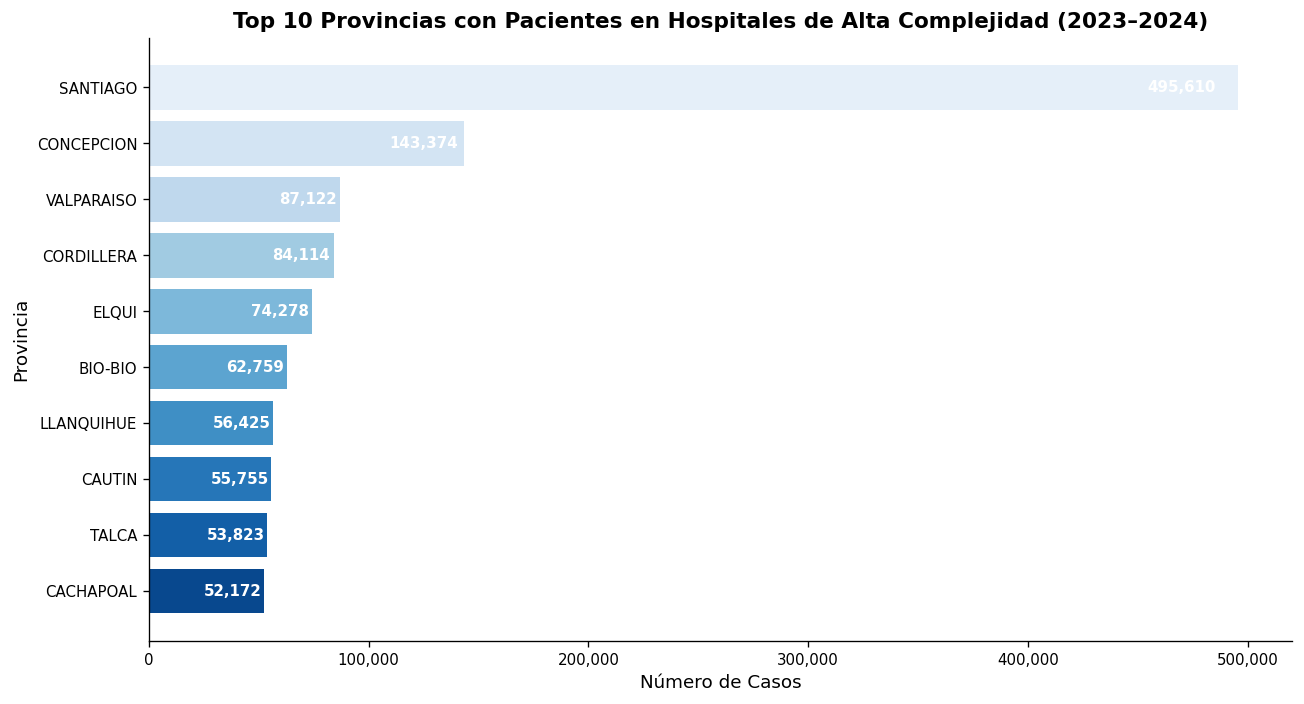

In [36]:
top_provincias = GRD_ALTA["PROVINCIA"].value_counts().head(10)

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(
    top_provincias.index[::-1],
    top_provincias.values[::-1],
    color=sns.color_palette(PALETTE, 10)
)
for bar, val in zip(bars, top_provincias.values[::-1]):
    ax.text(bar.get_width() * 0.98, bar.get_y() + bar.get_height() / 2,
            f"{val:,.0f}", va="center", ha="right", color="white", fontweight="bold", fontsize=9)
ax.set_title("Top 10 Provincias con Pacientes en Hospitales de Alta Complejidad (2023–2024)",
             fontweight="bold")
ax.set_xlabel("Número de Casos")
ax.set_ylabel("Provincia")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


### 4.2 Distribución de Casos por Servicio de Salud

Identifica cuáles Servicios de Salud concentran más hospitalizaciones de alta complejidad.


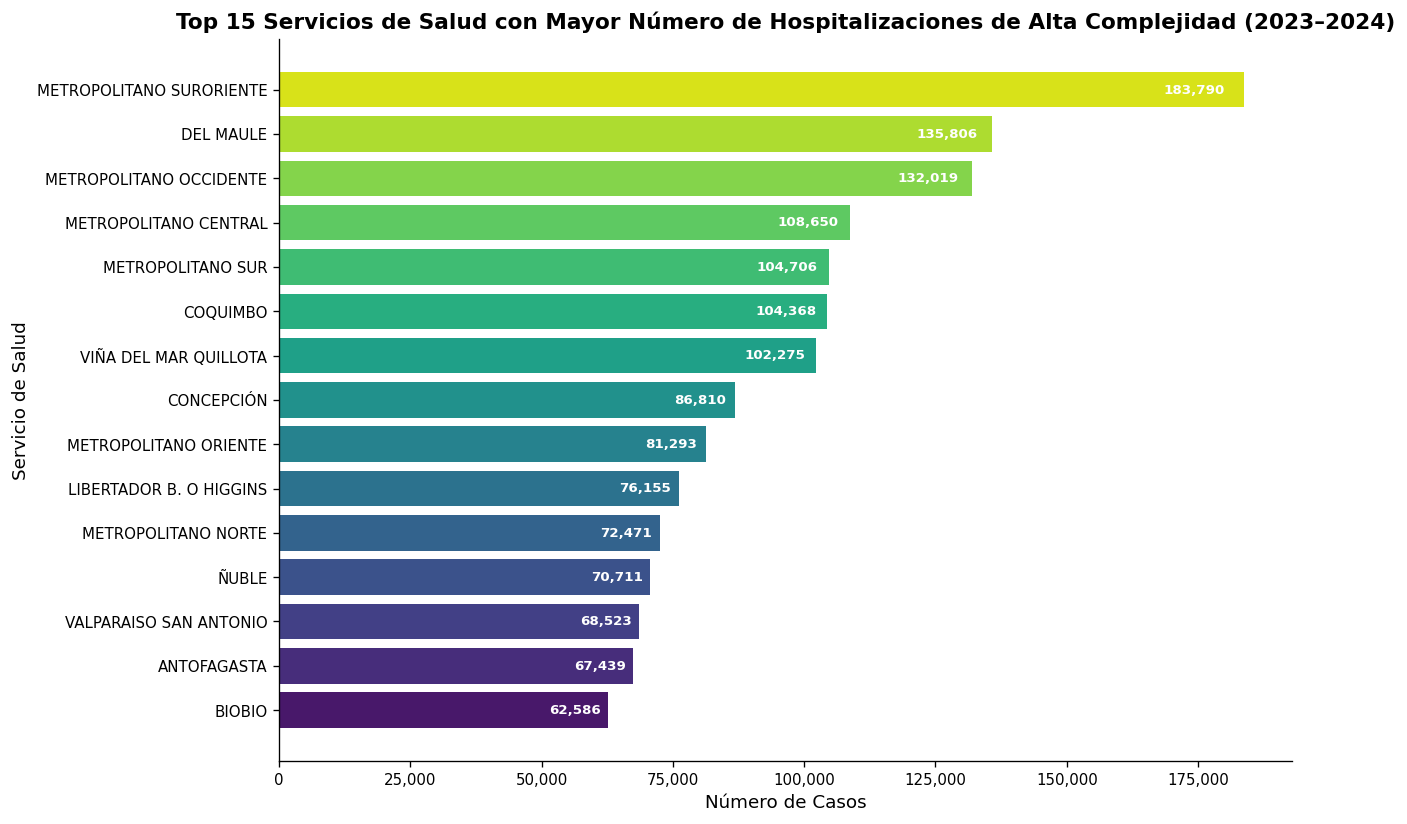

In [10]:
top_servicios = GRD_ALTA["SERVICIO_SALUD"].value_counts().head(15)

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(
    top_servicios.index[::-1],
    top_servicios.values[::-1],
    color=sns.color_palette("viridis", 15)
)
for bar, val in zip(bars, top_servicios.values[::-1]):
    ax.text(bar.get_width() * 0.98, bar.get_y() + bar.get_height() / 2,
            f"{val:,.0f}", va="center", ha="right", color="white", fontweight="bold", fontsize=8)
ax.set_title("Top 15 Servicios de Salud con Mayor Número de Hospitalizaciones de Alta Complejidad (2023–2024)",
             fontweight="bold")
ax.set_xlabel("Número de Casos")
ax.set_ylabel("Servicio de Salud")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


### 4.3 Distribución de la Estancia Hospitalaria


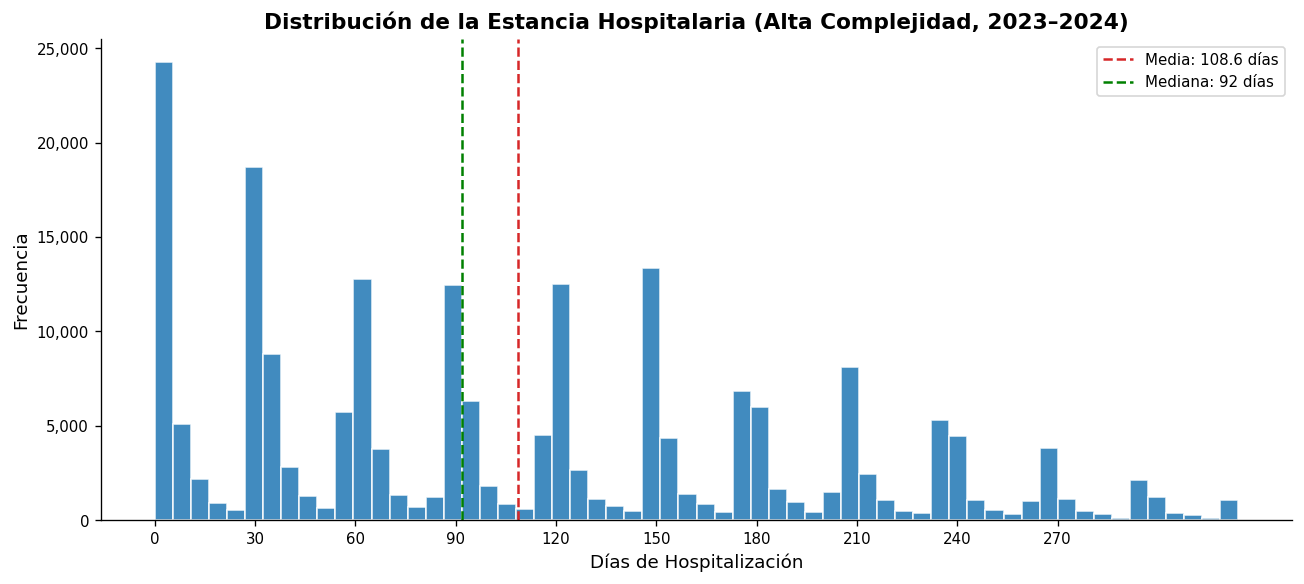

In [11]:
if "ESTANCIA_DIAS" in GRD_ALTA.columns:
    estancia_valida = GRD_ALTA["ESTANCIA_DIAS"].dropna()
    estancia_valida = estancia_valida[estancia_valida <= estancia_valida.quantile(0.99)]

    fig, ax = plt.subplots(figsize=(11, 5))
    ax.hist(estancia_valida, bins=60, color=COLOR_MAIN, edgecolor="white", alpha=0.85)
    media_est   = estancia_valida.mean()
    mediana_est = estancia_valida.median()
    ax.axvline(media_est,   color=COLOR_SEC, linestyle="--", lw=1.5, label=f"Media: {media_est:.1f} días")
    ax.axvline(mediana_est, color="green",   linestyle="--", lw=1.5, label=f"Mediana: {mediana_est:.0f} días")
    ax.set_title("Distribución de la Estancia Hospitalaria (Alta Complejidad, 2023–2024)", fontweight="bold")
    ax.set_xlabel("Días de Hospitalización")
    ax.set_ylabel("Frecuencia")
    ax.legend()
    ax.set_xticks(np.arange(0, 300, 30))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()
else:
    print("Columna ESTANCIA_DIAS no disponible.")


### 4.4 Mapa Geoespacial: Concentración de Hospitalizaciones por Hospital

El tamaño de cada punto es proporcional al número de hospitalizaciones,
evidenciando la concentración geográfica en el país.


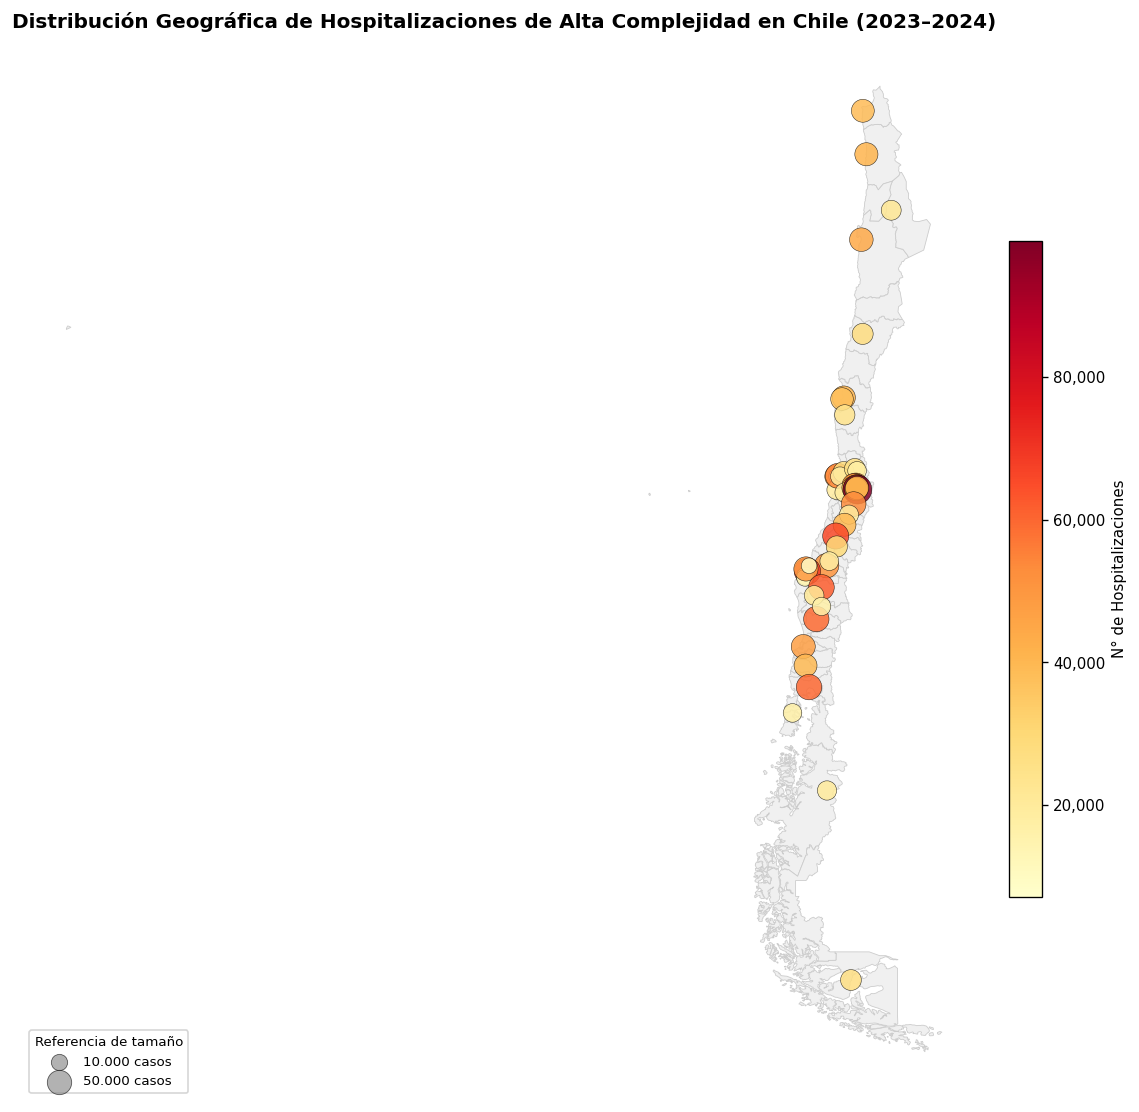

Hospitales graficados: 58
Hospital con más casos:  Complejo Hospitalario Dr. Sótero del Río (Santiago, Puente Alto) (99,064 casos)


In [12]:
# Casos por hospital con coordenadas
casos_hospital = (
    GRD_ALTA.groupby("COD_HOSPITAL")
    .agg(
        N_CASOS=("COD_HOSPITAL", "count"),
        NOMBRE=("NOMBRE_HOSPITAL", "first"),
        Latitud=("Latitud", "first"),
        Longitud=("Longitud", "first"),
        CIUDAD=("COMUNA_HOSP", "first")
    )
    .dropna(subset=["Latitud", "Longitud"])
    .reset_index()
)

geometry = geopandas.points_from_xy(casos_hospital["Longitud"], casos_hospital["Latitud"])
gdf_hospitales = geopandas.GeoDataFrame(casos_hospital, geometry=geometry, crs="EPSG:4326")
gdf_hospitales["MARKERSIZE"] = (gdf_hospitales["N_CASOS"] / gdf_hospitales["N_CASOS"].max()) ** 0.5 * 300

chile = geopandas.read_file(geodatasets.get_path("geoda.chile_labor"))

fig, ax = plt.subplots(figsize=(10, 14))
chile.plot(ax=ax, color="#f0f0f0", edgecolor="#cccccc", linewidth=0.5)
gdf_hospitales.plot(
    ax=ax, column="N_CASOS", cmap="YlOrRd",
    markersize=gdf_hospitales["MARKERSIZE"],
    legend=False, alpha=0.85, edgecolor="black", linewidth=0.3
)

sm = plt.cm.ScalarMappable(
    cmap="YlOrRd",
    norm=plt.Normalize(vmin=gdf_hospitales["N_CASOS"].min(), vmax=gdf_hospitales["N_CASOS"].max())
)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.4, pad=0.02)
cbar.set_label("N° de Hospitalizaciones", fontsize=9)
cbar.ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

ax.set_title("Distribución Geográfica de Hospitalizaciones de Alta Complejidad en Chile (2023–2024)",
             fontsize=12, fontweight="bold")
ax.set_axis_off()

for n, label in [(10_000, "10.000"), (50_000, "50.000"), (100_000, "100.000")]:
    if n <= gdf_hospitales["N_CASOS"].max():
        size = (n / gdf_hospitales["N_CASOS"].max()) ** 0.5 * 300
        ax.scatter([], [], s=size, c="gray", alpha=0.6, edgecolor="black", lw=0.5, label=f"{label} casos")
ax.legend(title="Referencia de tamaño", loc="lower left", fontsize=8, title_fontsize=8, framealpha=0.8)

plt.tight_layout()
plt.show()

print(f"Hospitales graficados: {len(gdf_hospitales)}")
print(f"Hospital con más casos: {gdf_hospitales.loc[gdf_hospitales.N_CASOS.idxmax(), 'NOMBRE']} "
      f"({gdf_hospitales['N_CASOS'].max():,} casos)")


---
## 5. Estimación Estadística


### 5.1 Proporción de Casos Graves por Servicio de Salud

Calculamos la **proporción de casos con severidad Mayor** (nivel 3) en cada
Servicio de Salud para identificar diferencias regionales en gravedad.


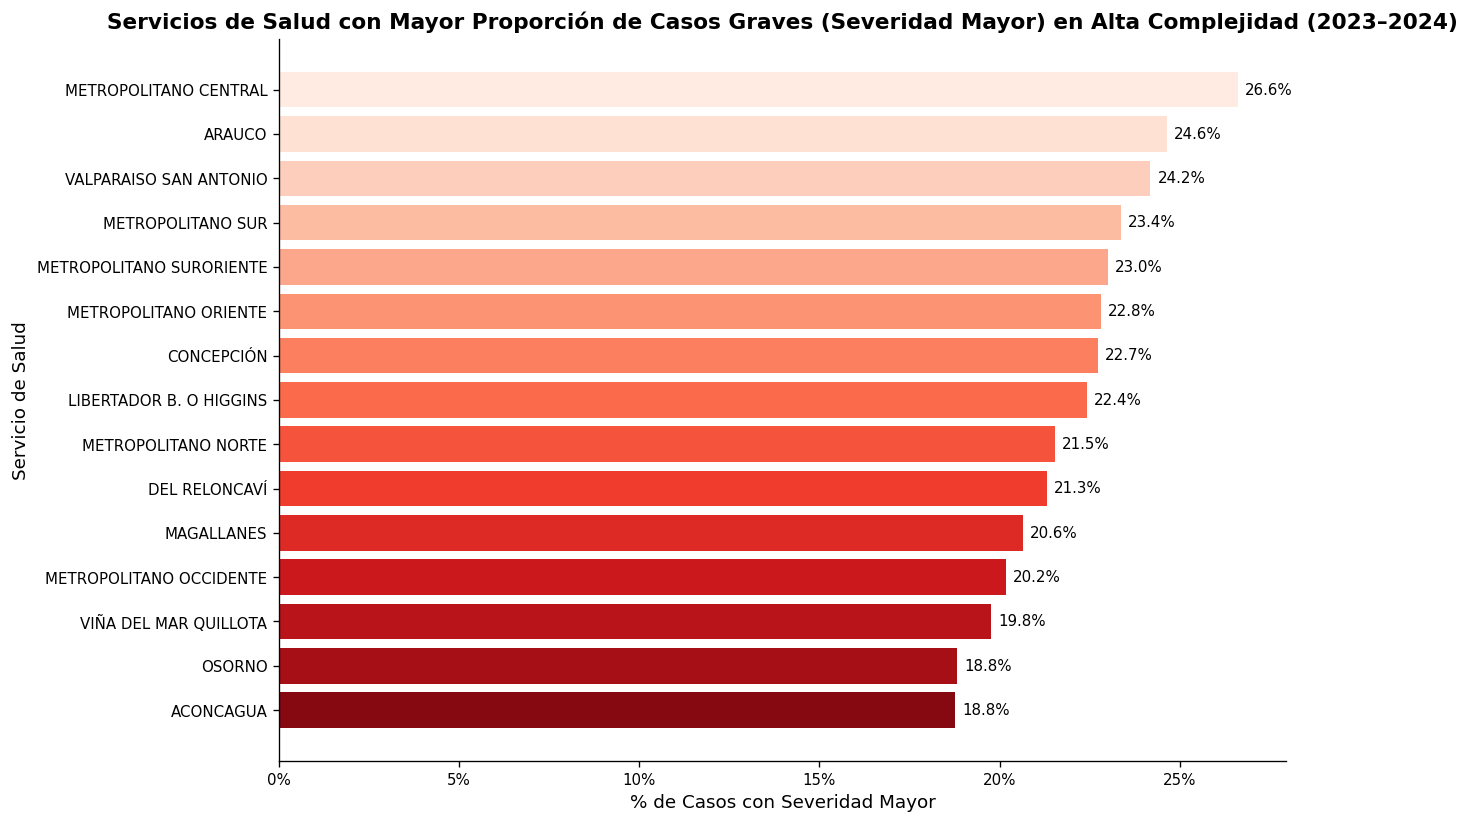

In [13]:
prop_graves = (
    GRD_ALTA.groupby("SERVICIO_SALUD")
    .agg(
        N_Total=("IR_29301_SEVERIDAD", "count"),
        N_Graves=("IR_29301_SEVERIDAD", lambda x: (x == 3).sum())
    )
    .query("N_Total >= 1000")
)
prop_graves["Prop_Graves"] = prop_graves["N_Graves"] / prop_graves["N_Total"]
prop_graves = prop_graves.sort_values("Prop_Graves", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(
    prop_graves.index[::-1],
    prop_graves["Prop_Graves"].values[::-1] * 100,
    color=sns.color_palette("Reds_r", len(prop_graves))
)
for bar, val in zip(bars, prop_graves["Prop_Graves"].values[::-1]):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height() / 2,
            f"{val:.1%}", va="center", fontsize=9)
ax.set_title("Servicios de Salud con Mayor Proporción de Casos Graves (Severidad Mayor) en Alta Complejidad (2023–2024)",
             fontweight="bold")
ax.set_xlabel("% de Casos con Severidad Mayor")
ax.set_ylabel("Servicio de Salud")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


---
## 6. Análisis de Flujo de Pacientes


### 6.1 Foráneos por Región Hospitalaria

Determinamos si un paciente es **foráneo** cuando fue atendido en una región
distinta a la región esperada según su provincia de residencia.


In [15]:
# Obtener región del hospital desde establecimientos
est_region = (
    establecimientosAlta[["EstablecimientoCodigo", "RegionGlosa", "RegionCodigo"]]
    .drop_duplicates("EstablecimientoCodigo")
)

GRD_ALTA = GRD_ALTA.merge(
    est_region, left_on="COD_HOSPITAL", right_on="EstablecimientoCodigo", how="left"
).drop(columns=["EstablecimientoCodigo"])

GRD_ALTA["REGION_HOSPITAL"] = GRD_ALTA["RegionGlosa"].str.strip().str.upper()
GRD_ALTA["PROVINCIA_PAC"]   = GRD_ALTA["PROVINCIA"].str.strip().str.upper()

# Inferir región esperada del paciente por moda de provincia
provincia_a_region = (
    GRD_ALTA[GRD_ALTA["REGION_HOSPITAL"].notna()]
    .groupby("PROVINCIA_PAC")["REGION_HOSPITAL"]
    .agg(lambda x: x.mode()[0] if len(x) > 0 else None)
    .reset_index()
    .rename(columns={"REGION_HOSPITAL": "REGION_ESPERADA_PAC"})
)
GRD_ALTA = GRD_ALTA.merge(provincia_a_region, on="PROVINCIA_PAC", how="left")

# Indicador de foráneo por región
GRD_ALTA["FORANEO"] = (
    GRD_ALTA["REGION_HOSPITAL"].notna() &
    GRD_ALTA["REGION_ESPERADA_PAC"].notna() &
    (GRD_ALTA["REGION_HOSPITAL"] != GRD_ALTA["REGION_ESPERADA_PAC"])
)

total   = GRD_ALTA["FORANEO"].notna().sum()
foraneos = GRD_ALTA["FORANEO"].sum()
print(f"Total registros con región identificada: {total:,}")
print(f"Pacientes foráneos (fuera de su región):  {foraneos:,} ({foraneos/total:.1%})")
print(f"Pacientes locales (en su propia región):  {total-foraneos:,} ({(total-foraneos)/total:.1%})")


Total registros con región identificada: 1,987,858
Pacientes foráneos (fuera de su región):  42,112 (2.1%)
Pacientes locales (en su propia región):  1,945,746 (97.9%)


### 6.2 Foráneos por Comuna


In [16]:
total_c   = GRD_ALTA["FORANEO_COMUNA"].notna().sum()
foraneos_c = GRD_ALTA["FORANEO_COMUNA"].sum()
print(f"Total registros con comuna identificada:        {total_c:,}")
print(f"Pacientes foráneos por comuna:                  {foraneos_c:,} ({foraneos_c/total_c:.1%})")
print(f"Pacientes locales por comuna:                   {total_c-foraneos_c:,} ({(total_c-foraneos_c)/total_c:.1%})")


Total registros con comuna identificada:        1,987,858
Pacientes foráneos por comuna:                  965,528 (48.6%)
Pacientes locales por comuna:                   1,022,330 (51.4%)


### 6.3 Crosstab Foráneos por Región Hospitalaria


In [17]:
crosstab = pd.crosstab(GRD_ALTA["REGION_HOSPITAL"], GRD_ALTA["FORANEO"], margins=True)
crosstab.columns = ["Local", "Foráneo", "Total"]
print("Tabla de contingencia: pacientes locales vs foráneos por región hospitalaria")
display(crosstab.sort_values("Foráneo", ascending=False))

print("Tabla normalizada (proporción por región):")
crosstab_norm = crosstab.div(crosstab["Total"], axis=0).sort_values("Foráneo", ascending=False)
display(crosstab_norm)


Tabla de contingencia: pacientes locales vs foráneos por región hospitalaria


,Local,Foráneo,Total
REGION_HOSPITAL,,,
All,1945746,42112,1987858
REGIÓN METROPOLITANA DE SANTIAGO,678895,18995,697890
REGIÓN DEL BÍOBÍO,210746,4833,215579
REGIÓN DE VALPARAÍSO,211885,3264,215149
REGIÓN DE LOS LAGOS,113544,2861,116405
REGIÓN DEL LIBERTADOR GRAL. B. O'HIGGINS,70475,1912,72387
REGIÓN DE LA ARAUCANÍA,95078,1738,96816
REGIÓN DE LOS RÍOS,45680,1707,47387
REGIÓN DEL MAULE,132611,1620,134231


Tabla normalizada (proporción por región):


,Local,Foráneo,Total
REGION_HOSPITAL,,,
REGIÓN DE LOS RÍOS,0.963977,0.036023,1.0
REGIÓN METROPOLITANA DE SANTIAGO,0.972782,0.027218,1.0
REGIÓN DEL LIBERTADOR GRAL. B. O'HIGGINS,0.973586,0.026414,1.0
REGIÓN DE LOS LAGOS,0.975422,0.024578,1.0
REGIÓN DE ANTOFAGASTA,0.976254,0.023746,1.0
REGIÓN DEL BÍOBÍO,0.977581,0.022419,1.0
All,0.978815,0.021185,1.0
REGIÓN DE LA ARAUCANÍA,0.982048,0.017952,1.0
REGIÓN DE ÑUBLE,0.982929,0.017071,1.0


### 6.4 Top Comunas de Origen de Pacientes Foráneos


In [18]:
comunas_foraneas = (
    GRD_ALTA[GRD_ALTA["FORANEO_COMUNA"]]
    .groupby("COMUNA_PAC").size()
    .reset_index(name="N_FORANEOS")
    .query("N_FORANEOS > 100")
    .sort_values("N_FORANEOS", ascending=False)
)
print(f"Comunas con más de 100 pacientes foráneos: {len(comunas_foraneas)}")
print("Top 10 comunas de origen de pacientes foráneos:")
display(comunas_foraneas.head(10))


Comunas con más de 100 pacientes foráneos: 329
Top 10 comunas de origen de pacientes foráneos:


,COMUNA_PAC,N_FORANEOS
125,LA PINTANA,25873
233,PUDAHUEL,21854
84,EL BOSQUE,18994
266,RENCA,18379
91,ESTACION CENTRAL,18067
258,QUINTA NORMAL,15413
122,LA GRANJA,15210
71,COYHAIQUE,14799
300,SAN PEDRO DE LA PAZ,14207
107,HUALPEN,13772


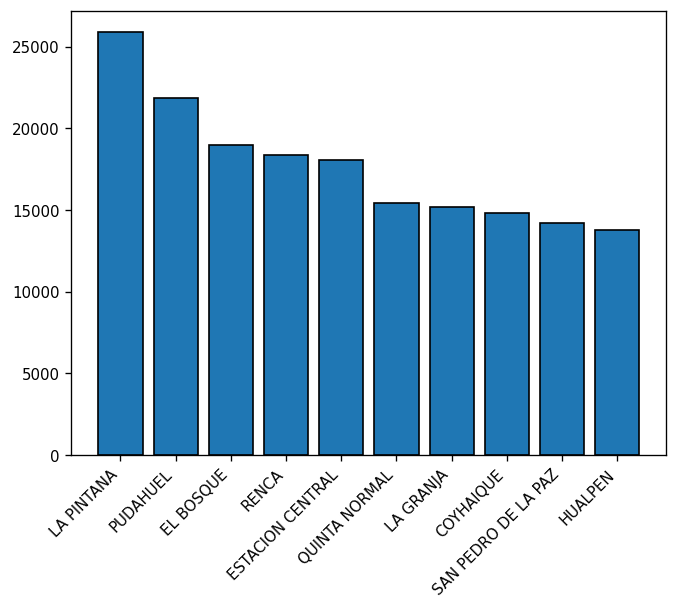

In [19]:
plt.bar(comunas_foraneas["COMUNA_PAC"].head(10), comunas_foraneas["N_FORANEOS"].head(10), color=COLOR_MAIN, edgecolor="black")
plt.xticks(rotation=45, ha="right")
plt.show()

In [27]:
foraneo_total = len(GRD_ALTA[GRD_ALTA["FORANEO_COMUNA"] == True])
no_foraneo_total = len(GRD_ALTA[GRD_ALTA["FORANEO_COMUNA"] == False])
total = len(GRD_ALTA)
alpha = 0.05

hosp1_prop = foraneo_total / total
hosp2_prop = no_foraneo_total / total

# Prueba para dos proporciones
count = np.array([foraneo_total, no_foraneo_total])
nobs = np.array([total, total])

z_stat, p_valor = sm.stats.proportions_ztest(count, nobs)

# IC para foráneos
ic_foraneo = proportion_confint(foraneo_total, total, alpha=0.05, method="wilson")

# IC para locales
ic_local = proportion_confint(no_foraneo_total, total, alpha=0.05, method="wilson")

print(f"IC 95% proporción foráneos: [{ic_foraneo[0]:.4f}, {ic_foraneo[1]:.4f}]")
print(f"IC 95% proporción locales:  [{ic_local[0]:.4f}, {ic_local[1]:.4f}]")

# Mostrar resultados
print(f"Prueba Z para proporcion de pacientes foraneos vs no foraneos por comuna")
print(f"Hipótesis nula (H₀): La proporcion de pacientes foraneos es mayor a la de pacientes locales")
print(f"Hipótesis alternativa (H₁): La proporcion de pacientes foraneos menor o igual a la de pacientes locales")
print(f"Proporción de pacientes foraneos: {hosp1_prop:.4f} ({foraneo_total}/{total})")
print(f"Proporción de pacientes no foraneos: {hosp2_prop:.4f} ({no_foraneo_total}/{total})")
print(f"Diferencia de proporciones: {hosp2_prop - hosp1_prop:.4f}")
print(f"Estadística Z: {z_stat:.4f}")
print(f"Valor p: {p_valor:.4f}")

# Decisión estadística
if p_valor < alpha:
    print(f"Decisión: Rechazamos la hipótesis nula (p < {alpha})")
    print(f"Conclusión: Existe una diferencia significativa en la tasa de complicaciones entre los hospitales")
else:
    print(f"Decisión: No rechazamos la hipótesis nula (p ≥ {alpha})")
    print(f"Conclusión: No hay evidencia suficiente para afirmar que existe diferencia en la tasa de complicaciones")


IC 95% proporción foráneos: [0.4850, 0.4864]
IC 95% proporción locales:  [0.5136, 0.5150]
Prueba Z para proporcion de pacientes foraneos vs no foraneos por comuna
Hipótesis nula (H₀): La proporcion de pacientes foraneos es mayor a la de pacientes locales
Hipótesis alternativa (H₁): La proporcion de pacientes foraneos menor o igual a la de pacientes locales
Proporción de pacientes foraneos: 0.4857 (965528/1987858)
Proporción de pacientes no foraneos: 0.5143 (1022330/1987858)
Diferencia de proporciones: 0.0286
Estadística Z: -56.9752
Valor p: 0.0000
Decisión: Rechazamos la hipótesis nula (p < 0.05)
Conclusión: Existe una diferencia significativa en la tasa de complicaciones entre los hospitales


---
## 7. Modelo de Regresión Lineal

Se ajusta un modelo OLS para predecir el **peso GRD** () en función
de variables clínicas, geográficas y demográficas.

**Variables predictoras:**
-  – Región donde se ubica el hospital
-  – Macrozona de origen del paciente *(nueva variable)*
-  – Severidad clínica del episodio
-  – Si el paciente es foráneo a nivel comunal
-  – Sexo del paciente


In [30]:
# Eliminar filas con NaN en las variables del modelo
vars_modelo = ["IR_29301_PESO", "REGION_HOSPITAL", "IR_29301_SEVERIDAD",
               "IR_29301_MORTALIDAD", "FORANEO_COMUNA", "SEXO",
               "TIPOALTA", "ESPECIALIDAD_MEDICA", "TIPO_PROCEDENCIA",
               "N_PROCEDIMIENTOS", "N_DIAGNOSTICOS"]
GRD_modelo = GRD_ALTA.dropna(subset=vars_modelo).copy()
# Excluir macrozona desconocida
GRD_modelo = GRD_modelo[GRD_modelo["MACROZONA_HOSP"] != "Desconocida"]

print(f"Registros usados en el modelo: {len(GRD_modelo):,}")
print(f"Distribución de macrozona en el modelo: {GRD_modelo['MACROZONA_HOSP'].value_counts().to_string()}")


Registros usados en el modelo: 1,669,386
Distribución de macrozona en el modelo: MACROZONA_HOSP
Centro          779706
Centro-Sur      361503
Centro-Norte    217475
Norte           136622
Sur             126748
Austral          47332


In [31]:
train, test = train_test_split(GRD_modelo, test_size=0.05, random_state=42)

modelo = smf.ols(
    """IR_29301_PESO ~ C(REGION_HOSPITAL) + C(IR_29301_SEVERIDAD)
                    + C(IR_29301_MORTALIDAD) + C(FORANEO_COMUNA) + C(SEXO)
                    + C(TIPOALTA) + C(ESPECIALIDAD_MEDICA) + C(TIPO_PROCEDENCIA)
                    + N_PROCEDIMIENTOS + N_DIAGNOSTICOS""",
    data=train
).fit()

print(modelo.summary())


                            OLS Regression Results                            
Dep. Variable:          IR_29301_PESO   R-squared:                       0.447
Model:                            OLS   Adj. R-squared:                  0.447
Method:                 Least Squares   F-statistic:                 1.061e+04
Date:               mar, 05 may. 2026   Prob (F-statistic):               0.00
Time:                        22:37:50   Log-Likelihood:            -1.9442e+06
No. Observations:             1585916   AIC:                         3.889e+06
Df Residuals:                 1585794   BIC:                         3.890e+06
Df Model:                         121                                         
Covariance Type:            nonrobust                                         
                                                                                                   coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------

In [32]:
pred = modelo.predict(test)

mae  = mean_absolute_error(test["IR_29301_PESO"], pred)
rmse = np.sqrt(mean_squared_error(test["IR_29301_PESO"], pred))
r2   = r2_score(test["IR_29301_PESO"], pred)

print("Métricas de evaluación del modelo (conjunto de prueba):")
print(f"  MAE:  {mae:.4f}")
print(f"  RMSE: {rmse:.4f}")
print(f"  R²:   {r2:.4f}")


Métricas de evaluación del modelo (conjunto de prueba):
  MAE:  0.4180
  RMSE: 0.8001
  R²:   0.4538


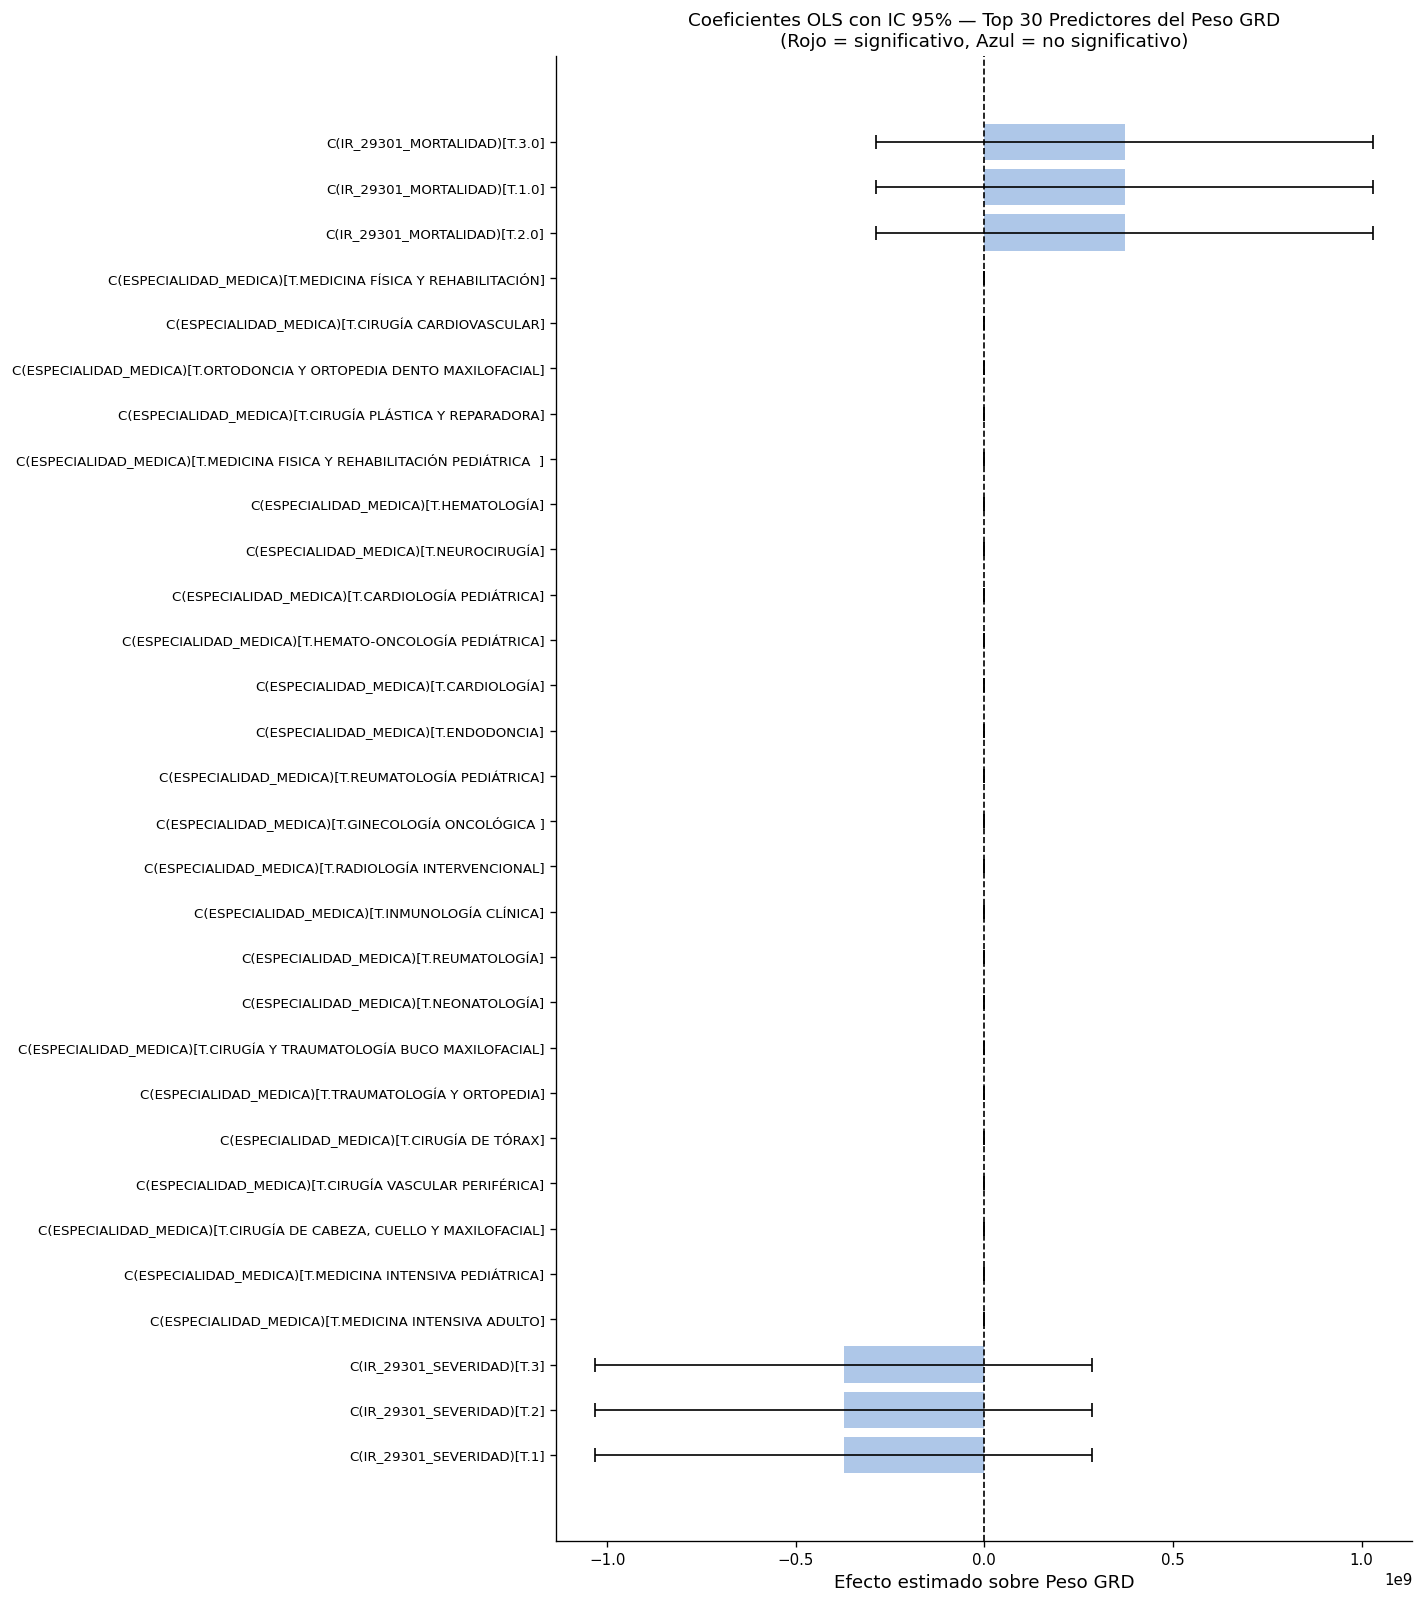

In [37]:
# Extraer coeficientes e IC del modelo
coef_df = pd.DataFrame({
    "coef":    modelo.params,
    "ic_low":  modelo.conf_int()[0],
    "ic_high": modelo.conf_int()[1]
}).drop("Intercept").reset_index()
coef_df.columns = ["Variable", "Coef", "IC_Low", "IC_High"]

# Filtrar solo variables significativas (IC no cruza el cero)
coef_df["Sig"] = ~((coef_df["IC_Low"] < 0) & (coef_df["IC_High"] > 0))

# ── OPCIÓN A: Mostrar solo los Top N por magnitud de efecto (recomendado) ──
TOP_N = 30
coef_plot = (
    coef_df
    .assign(abs_coef=coef_df["Coef"].abs())
    .sort_values("abs_coef", ascending=False)
    .head(TOP_N)
    .sort_values("Coef")          # orden visual: menor a mayor
)

# ── Tamaño dinámico según número de variables ──
fig_height = max(8, len(coef_plot) * 0.45)
fig, ax = plt.subplots(figsize=(12, fig_height))

colors = ["#d62728" if sig else "#aec7e8" for sig in coef_plot["Sig"]]

ax.barh(
    coef_plot["Variable"],
    coef_plot["Coef"],
    xerr=[
        coef_plot["Coef"] - coef_plot["IC_Low"],
        coef_plot["IC_High"] - coef_plot["Coef"]
    ],
    color=colors,
    capsize=4,
    error_kw={"ecolor": "black", "elinewidth": 1}
)

ax.axvline(0, color="black", linestyle="--", lw=1)
ax.set_title(f"Coeficientes OLS con IC 95% — Top {TOP_N} Predictores del Peso GRD\n"
             "(Rojo = significativo, Azul = no significativo)", fontsize=11)
ax.set_xlabel("Efecto estimado sobre Peso GRD")
ax.tick_params(axis="y", labelsize=8)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

---
## Fuentes de Datos

- **FONASA – GRD 2023 y 2024:** Agrupación de pacientes por GRD, sistema público de salud.
- **Ministerio de Salud – Establecimientos de Salud Vigentes:**
  https://datos.gob.cl/dataset/establecimientos-de-salud-vigentes/resource/2c44d782-3365-44e3-aefb-2c8b8363a1bc
